### Students name 
`Loginova Olga`

### Contents
`Part 0` **Settings and Imports**\
\
`Part 1` **Data Preparation**
-  Loading Metadata, Counts Matrix, and Gene Annotations
-  Filtering by Sequencing Depth (≥5M reads)
-  Normalization: Counts → log₂(TPM+1)
-  Visualization of Key Biological Signatures

`Part 2A` **PCA and Clustering**
-  PCA and Stratification by Meta-Features (Batch, Diagnosis, Ethnicity, etc.)
-  Clustering (Agglomerative Clustering, k optimization by Silhouette)
-  Сorrection of batch effect


`Part 2B` **Machine Learning: IFN Status Prediction**
-  Type I IFN Gene Expression by Diagnosis
-  Median IFN score by cohort
-  Random Forest training + thresholding (F1, CV)
-  Validation: Confusion Matrix, Classification Report
-  Interpretation: SHAP, Gini importance, gene correlation
-  Visualization of IFN Probability predictions by Batch/Diagnosis


### Part 0. Settings and imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import warnings, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import shap
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix, silhouette_score, roc_auc_score, auc, roc_curve
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import kruskal, gaussian_kde, zscore
from matplotlib.colors import to_rgba

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 3)
plt.rcParams['font.size'] = 10

### Part 1. Data preparation

####  Loading Metadata, Counts Matrix, and Gene Annotations

In [2]:
# Metadata
metadata = pd.read_csv('../data/metadata.csv', sep=',', index_col=1)
metadata

,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,disease_type,country,state_province,continent,ifn_status
SRR,,,,,,,,,,,,,
SRR13810601,GSE167923,whole_blood,CLE,F,NaN,C,total,NaN,SCLE,USA,Texas,North America,NaN
SRR13810602,GSE167923,whole_blood,CLE,F,NaN,AA,total,NaN,SCLE,USA,Texas,North America,NaN
SRR13810603,GSE167923,whole_blood,CLE,F,NaN,C,total,NaN,SCLE,USA,Texas,North America,NaN
SRR13810604,GSE167923,whole_blood,CLE,F,NaN,C,total,NaN,SCLE,USA,Texas,North America,NaN
SRR13810605,GSE167923,whole_blood,CLE,F,NaN,C,total,NaN,SCLE,USA,Texas,North America,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR7368030,GSE116006,whole_blood,SLE,F,34.0,NaN,polyA,Anti_IL6_MAB,SLE,United_Kingdom,Cambridgeshire,Europe,High
SRR7368040,GSE116006,whole_blood,SLE,F,37.0,NaN,polyA,Placebo,SLE,United_Kingdom,Cambridgeshire,Europe,NaN
SRR7368042,GSE116006,whole_blood,SLE,F,36.0,NaN,polyA,Anti_IL6_MAB,SLE,United_Kingdom,Cambridgeshire,Europe,High


#### FeatureCounts

**STAR** (Spliced Transcripts Alignment to a Reference) is an algorithm and software for highly accurate and ultra-fast alignment of RNA-seq data to a reference genome. To quantify reads per gene, STAR uses the --quantMode GeneCounts option. There is also the possibility of FeatureCounts after alignment using **subread** and *.bam

```bash
conda activate base
cd /home/bioinf2026/loginova/star

featureCounts 
    -p                  # paired-end mode \        
    -s 2                # strand specificity  (2 = reverse-stranded) \      
    -T 15               # threads number \     
    --primary           # сonsider only primary alignments and ignore secondary and chimeric ones \ 
    -a /home/bioinf2026/loginova/star/gencode.v38.annotation.gtf     # path to the GTF annotation \
    -t exon -g gene_id  # exon-level search and grouping by gene_id \                                       
    -o /home/bioinf2026/loginova/immune_counts_matrix_all.txt        # path to output file \    
    $(find /home/bioinf2026/sko1/results/results_star -name "*.sorted.bam" | sort) 
```

In [3]:
# Counts Matrix
counts = pd.read_csv('../data/counts_merged.csv', sep=',', index_col=0)
counts

,SRR10342368,SRR10342369,SRR10342370,SRR10342371,SRR12794681,SRR12794682,SRR12794683,SRR12794684,SRR12794685,SRR12794686,...,SRR8181373,SRR8181374,SRR8181375,SRR8181376,SRR8181377,SRR8181378,SRR8181379,SRR8181380,SRR8181381,SRR8181382
Geneid,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,0,21,4,2,2,0,0,0,0,0,...,2,6,0,1,2,0,0,1,1,1
5_8S_rRNA,1,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7SK,0,0,0,0,6,4,3,1,2,3,...,0,0,0,0,0,0,0,0,0,0
A1BG,2,8,7,0,12,21,25,26,4,28,...,18,11,22,17,52,44,25,50,13,22
A1BG-AS1,130,232,151,332,111,217,118,125,193,278,...,164,199,288,193,300,292,320,401,366,578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZZZ3,213,1012,1201,374,2253,1938,1511,1583,2090,2615,...,1671,1374,1567,1098,1903,1686,1362,1435,2355,2853
hsa-mir-1253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
hsa-mir-423,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,2,0,0,3,0,0


In [4]:
# Gene Annotations/ Mapping dict (DDX11L1 | ENSG00000223972 | Lenght)
mapping_dict = pd.read_csv('../data/genes_ensembl_length.csv', sep=',', index_col=0)
mapping_dict

,Ensembl,Length
Geneid,,
A1BG,ENSG00000121410,8315.0
A1CF,ENSG00000148584,86308.0
A2M,ENSG00000175899,48566.0
A2ML1,ENSG00000166535,64381.0
A4GALT,ENSG00000128274,30289.0
...,...,...
ZXDC,ENSG00000070476,38393.0
ZYG11B,ENSG00000162378,100890.0
ZYX,ENSG00000159840,9817.0


#### Filtering by Sequencing Depth (≥5M reads)

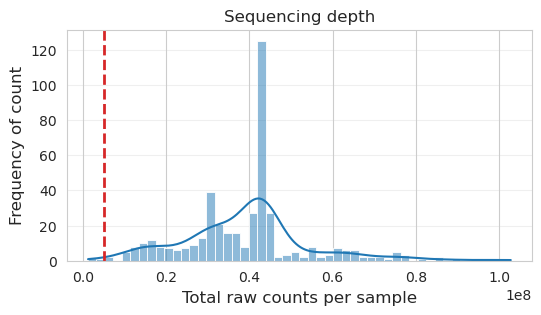

433 samples have ≥ 5M counts
counts_more5: 59268 rows × 433 cols


In [5]:
# KDE plot 
sample_sums = counts.sum(axis=0)  # sum over genes for each sample

# Visualisation 
sns.histplot(sample_sums, bins=50, kde=True, color='#1f77b4', alpha=0.5)
plt.axvline(x=5_000_000, color='#d62728', linestyle='--', linewidth=2, label='Cutoff 5M reads')
plt.xlabel('Total raw counts per sample', fontsize=12)
plt.ylabel('Frequency of count', fontsize=12)
plt.title('Sequencing depth', fontsize=12)
plt.grid(axis='y', alpha=0.3)
# plt.savefig('counts_depth_5M_cutoff.png', dpi=300)
plt.show()

# Dept calculation and filtration
good_samples = counts.sum()[lambda s: s >= 5_000_000].index

# Refresh
counts_more5 = counts[good_samples]
metadata = metadata.loc[good_samples]

print(f"{len(good_samples)} samples have ≥ 5M counts")
print(f"counts_more5: {counts_more5.shape[0]} rows × {counts_more5.shape[1]} cols") 

In [6]:
valid_genes = mapping_dict.dropna(subset=['Ensembl']).index
common_counts = counts_more5.loc[counts_more5.index.intersection(valid_genes)]
print(f"common_counts: {common_counts.shape[0]} rows × {common_counts.shape[1]} cols") 

common_counts: 17298 rows × 433 cols


#### Normalization: Counts → log₂(TPM+1)  

In [7]:
lengths = mapping_dict.loc[common_counts.index, 'Length'] # nessesary for rpk
rpk = common_counts.div(lengths / 1000, axis=0)
log_tpm = np.log2(rpk.div(rpk.sum(axis=0), axis=1) * 1e6 + 1)

print(f"log_tpm: {log_tpm.shape[0]} rows × {log_tpm.shape[1]} cols")  

log_tpm: 17298 rows × 433 cols


####  Visualization of Key Biological Signatures

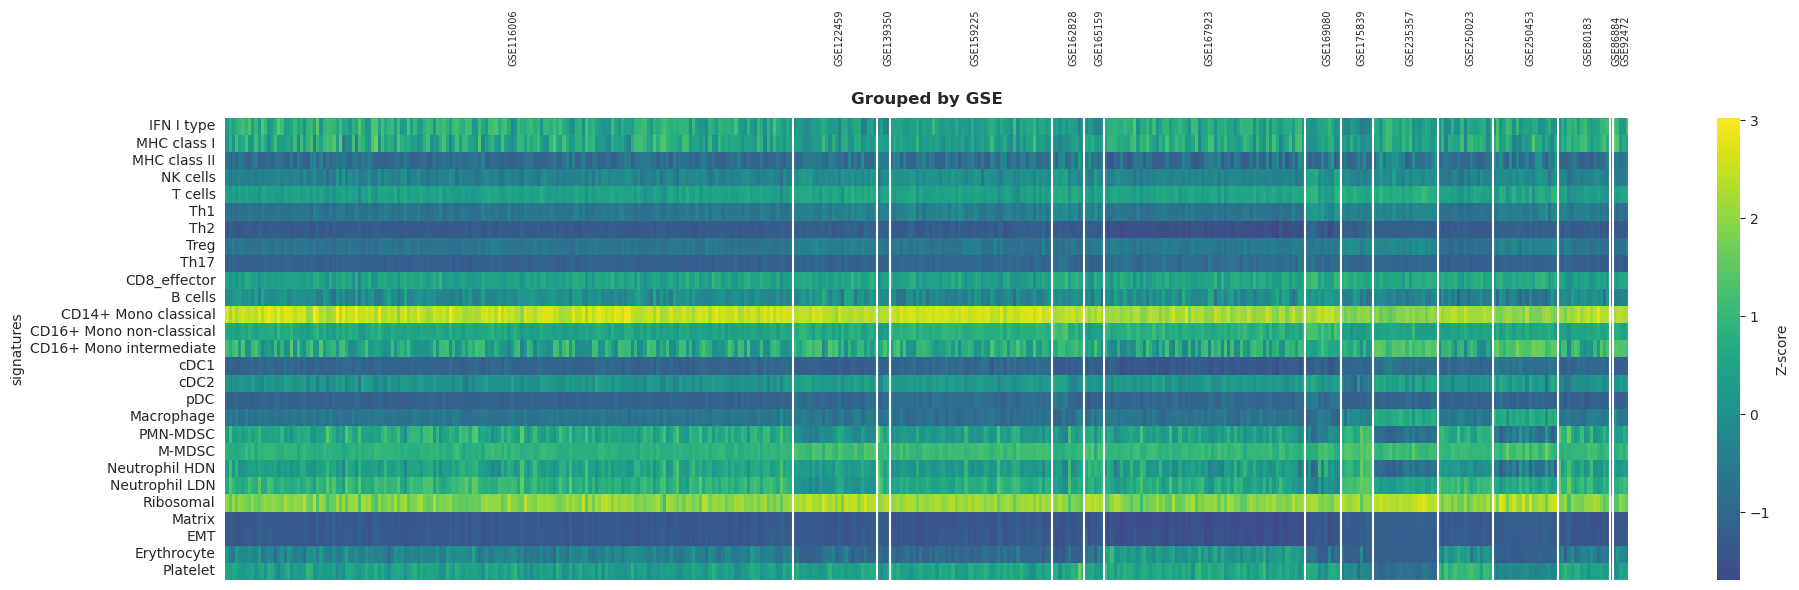

In [8]:
# Key signatures expression
signatures = {
    "IFN I type": ["IFI27", "IFIT1", "IFIT3", "MX1", "OAS1", "RSAD2", "STAT1", "IFNAR1", "IFNAR2"],

    "MHC class I": ["HLA-A", "HLA-B", "HLA-C", "B2M", "TAP1", "TAP2", "NLRC5", "TAPBP", "ISG15", "USP18", "IFI6", "RSAD2", "BST2"],
    "MHC class II": ["HLA-DRA", "HLA-DRB1", "HLA-DMA", "HLA-DPA1", "HLA-DPB1", "HLA-DMB", "HLA-DQB1", "HLA-DQA1", "CIITA"],
    
    "NK cells": ["NKG7", "CD160", "CD244", "NCR1", "KLRC2", "KLRK1", "CD226", "GZMH", "GNLY", "IFNG", "KIR2DL4", "EOMES", "GZMB", "FGFBP2", "KLRF1", "SH2D1B", "NCR3"],
    
    "T cells": ["TBX21", "ITK", "CD3D", "CD3E", "CD3G", "TRAC", "TRBC1", "TRBC2", "CD28", "CD5", "TRAT1"],
    "Th1": ["IFNG", "TBX21", "STAT4", "IL12RB2"],
    "Th2": ["IL4", "IL5", "IL13"],
    "Treg": ["FOXP3", "CTLA4", "IL10", "TNFRSF18", "CCR8", "IKZF4", "IKZF2"],
    "Th17": ["RORC", "IL17A", "IL23R", "CCR6", "STAT3"],
    
    "CD8_effector": ["CD8A","CD8B","GZMB","PRF1","IFNG","TBX21","EOMES","CX3CR1"],
    
    "B cells": ["CD19", "MS4A1", "TNFRSF13C", "CR2", "TNFRSF17", "TNFRSF13B", "CD22", "CD79A", "CD79B", "BLK", "FCRL5", "PAX5", "STAP1"],
    
    "CD14+ Mono classical": ["CD14", "LYZ", "S100A8", "S100A9", "FCN1"],
    "CD16+ Mono non-classical": ["FCGR3A", "MS4A7", "LYN", "CX3CR1", "VCAN"],
    "CD16+ Mono intermediate": ["CD14", "FCGR3A", "HLA-DRB1", "CD163", "MERTK"],
    
    "cDC1": ["CLEC9A", "XCR1", "CADM1", "BATF3", "IRF8"],
    "cDC2": ["FCER1A", "CST3", "CD1C", "IRF4", "CLEC10A"],
    
    "pDC": ["IL3RA", "TCF4", "GZMB", "LILRA4", "CLEC4C"],
    
    "Macrophage": ["CD68", "CSF1R", "MRC1", "MARCO", "CD163"],
    
    "PMN-MDSC": ["S100A8", "S100A9", "ARG1", "MMP9", "RETN", "CEACAM8", "LCN2"],
    "M-MDSC": ["CD14", "S100A8", "S100A9", "ARG1", "IDO1", "VEGFA"],
   
    "Neutrophil HDN": ["CEACAM8", "S100A8", "S100A9", "MMP8", "RETN"],
    "Neutrophil LDN": ["S100A8", "S100A9", "ARG1", "MMP9", "RETN", "LCN2"],
    
    "Ribosomal": ["RPLP0", "RPS18", "RPL13A", "RPS27"],
    "Matrix": ["FN1", "COL1A1", "COL1A2", "COL4A1", "COL3A1", "VTN", "LGALS7", "LGALS9", "LAMA3", "LAMB3", "LAMC2", "TNC", "ELN", "COL5A1", "COL11A1"],
    "EMT": ["SNAI1", "SNAI2", "TWIST1", "TWIST2", "ZEB1", "ZEB2", "CDH2"],
    "Erythrocyte": ["HBA1", "HBA2", "HBB","HBD", "HBE1", "HBG1", "HBG2", "HBZ", "ALAS2", "SLC4A1"],
    "Platelet": ["PPBP", "PF4", "GP9", "ITGA2B", "ITGB3", "GP1BA"]
}

# Z-scores 
scores_z = pd.DataFrame(
    {n: log_tpm.reindex(g).median() for n, g in signatures.items()}, 
    index=log_tpm.columns
).apply(zscore, axis=1, nan_policy='omit').fillna(0)

# Sorting by GSE
ms = metadata.sort_values('GSE')
ss = scores_z.reindex(ms.index)

# Visualisation (heatmap)
plt.figure(figsize=(20, 6))
ax = sns.heatmap(ss.T, cmap='viridis', center=0, cbar_kws={'label': 'Z-score'}, xticklabels=False)

grp = ms['GSE']
colors = plt.cm.tab20(np.linspace(0, 1, len(grp.unique())))
pos = 0
for i, g in enumerate(grp.unique()):
    n = (grp == g).sum()
    ax.axvspan(pos, pos+n, ymin=-0.12, ymax=0, color=colors[i], alpha=0.6)
    if i: ax.axvline(pos, color='white', lw=1.5, ymin=-0.15, ymax=1.05)
    ax.text(pos+n/2, -3, f"{g}", ha='left', va='bottom', fontsize=7, rotation=90)
    pos += n
ax.axvline(pos, color='white', lw=1.5, ymin=-0.15, ymax=1.05)

plt.ylabel('signatures')
plt.title('Grouped by GSE', pad=10, fontweight='bold')
plt.tight_layout()
plt.show()

There are some hints that samples may differ depending on the study (three types of objects: whole blood, leukocytes, PBMS, as well as three types of RNA: total, mRNA + polyA)

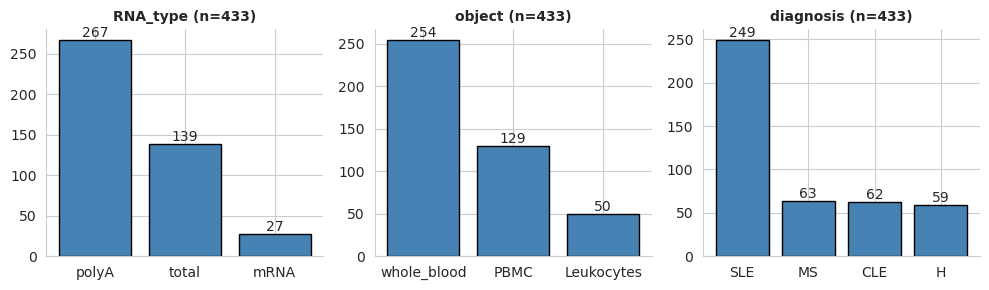

In [9]:
# Samples distribution by 'RNA_type', 'object', 'diagnosis'
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, col in zip(axes, ['RNA_type', 'object', 'diagnosis']):
    counts = metadata[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} (n={len(metadata)})', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # number
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

### Part 2A. PCA and Clustering

#### PCA and Stratification by Meta-Features

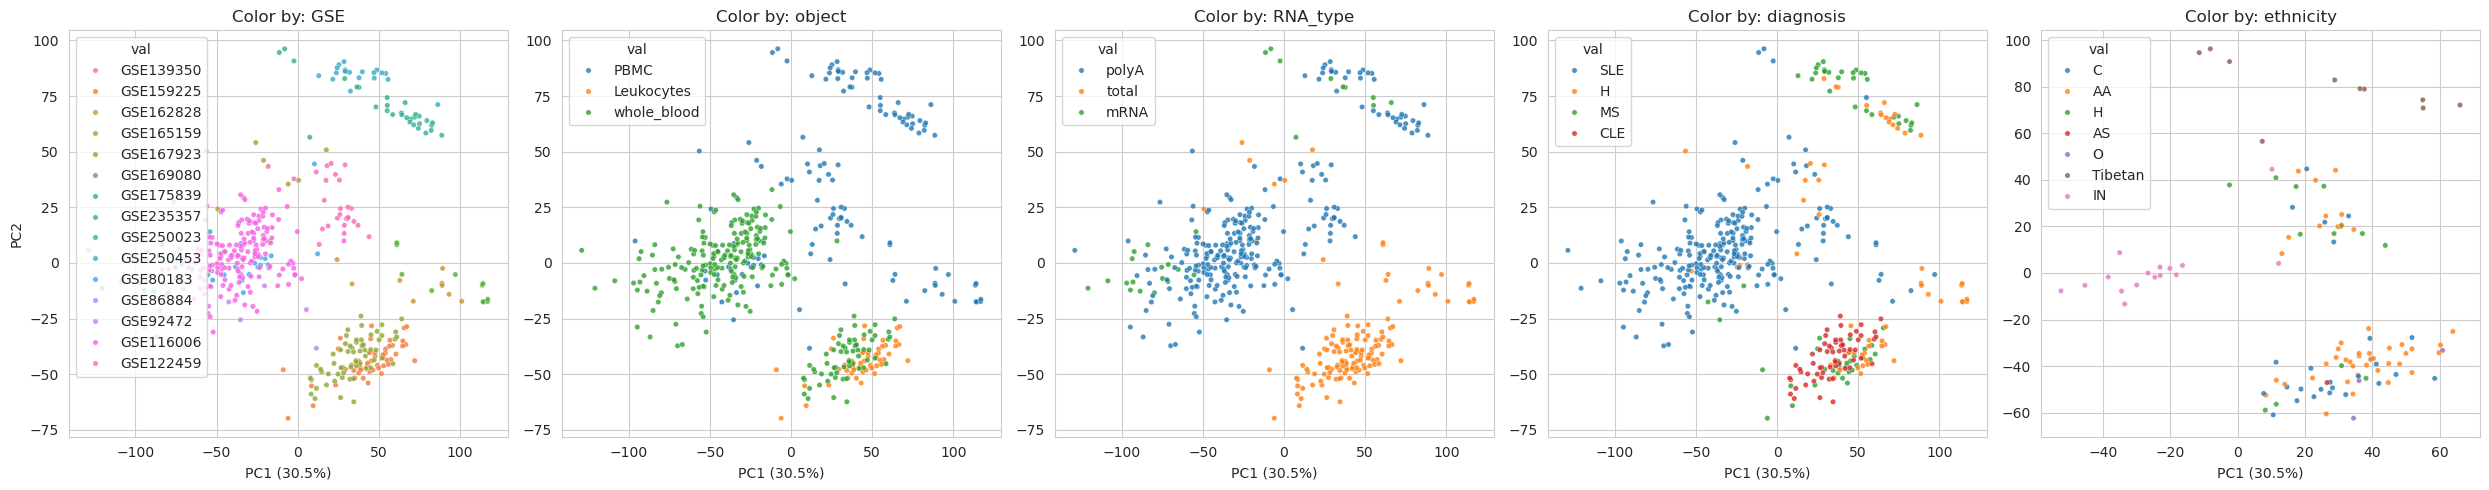

In [10]:
pca = PCA(n_components=2)
coords = pca.fit_transform(log_tpm.T)

cols_to_check = ['GSE', 'object', 'RNA_type', 'diagnosis', 'ethnicity'] 

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(25, 5))
for i, col in enumerate(cols_to_check):
    df_tmp = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1], 'val': metadata[col]})
    sns.scatterplot(data=df_tmp, x='PC1', y='PC2', hue='val', ax=axes[i], s=15, alpha=0.8)
    axes[i].set_title(f'Color by: {col}')
    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[i].set_ylabel('PC2' if i == 0 else '')
    
plt.tight_layout()
#plt.savefig('pca.png', dpi=300)
plt.show()

This partially confirms that the RNA type and object matter, as does the diagnosis. We'll perform clustering to further eliminate the batch effect where necessary. \

P.S. The Random Forest classifier is used below - it's insensitive to this kind of data difference.

In [11]:
# Assembling the table: PCA coordinates + metadata
plot_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1]}, index=log_tpm.columns)
plot_df = plot_df.join(metadata)  # synchronization by sample indices

#### Clustering (Agglomerative Clustering, k optimization by Silhouette)

Optimal cluster number based on Silhouette Score: 3


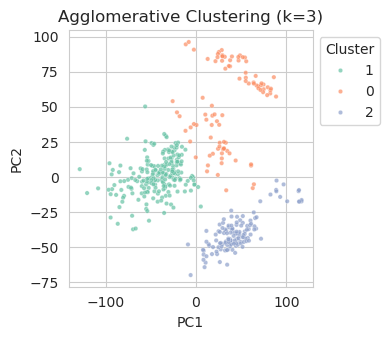

Cluster Distribution
Batch
0     94
1    212
2    127
Name: count, dtype: int64


In [12]:
# Create df
plot_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1]}, index=log_tpm.columns)
plot_df = plot_df.join(metadata)  

# Selection of optimal cluster number (k)
X = plot_df[['PC1', 'PC2']]
scores = [silhouette_score(X, AgglomerativeClustering(n_clusters=k).fit_predict(X)) for k in range(2, 10)]
best_k = np.argmax(scores) + 2
print(f"Optimal cluster number based on Silhouette Score: {best_k}")

# Clustering 
clusterer = AgglomerativeClustering(n_clusters=best_k)
plot_df['Batch'] = clusterer.fit_predict(X).astype(str)
metadata['Batch'] = plot_df['Batch']
# metadata.to_csv('metadata_with_batch.csv', index=True) # save to csv

# Visualisation
plt.figure(figsize=(4, 3.5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Batch', s=10, alpha=0.7, palette='Set2')
plt.title(f'Agglomerative Clustering (k={best_k})')
plt.legend(bbox_to_anchor=(1, 1), title='Cluster')
plt.tight_layout()
#plt.savefig('clustering.png', dpi=300)
plt.show()

# Statistic
print("Cluster Distribution")
print(plot_df['Batch'].value_counts().sort_index())

In this analysis, unsupervised clustering on PCA coordinates (k=3) was performed for exploratory quality control. The resulting cluster labels were saved to metadata as a reference covariate to monitor potential confounding during differential expression analysis, but were not used for batch correction or primary modeling to preserve biologically relevant variation.

### Part 2B. Machine Learning: IFN Status Prediction

#### Type I IFN Gene Expression by Diagnosis

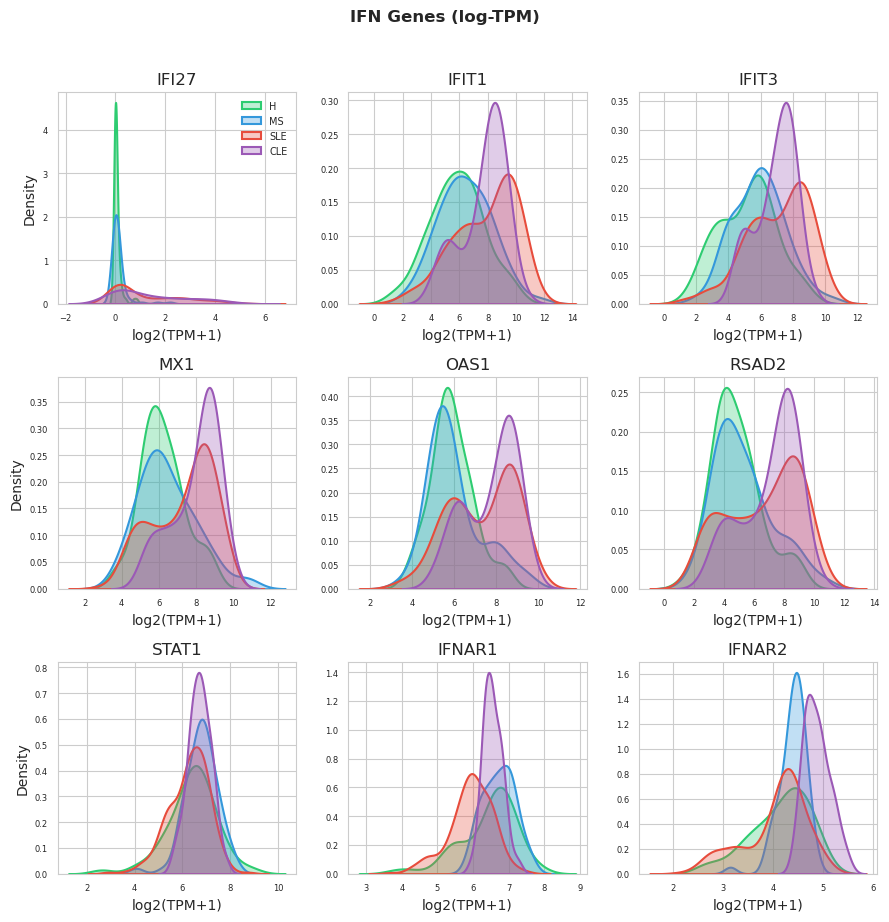

In [13]:
genes = [g for g in ["IFI27","IFIT1","IFIT3","MX1","OAS1","RSAD2","STAT1","IFNAR1","IFNAR2"] if g in log_tpm.index]

data = log_tpm.loc[genes].T  
pd_data = data.join(metadata[['diagnosis']], how='inner')
colors = {'H':'#2ecc71','MS':'#3498db','SLE':'#e74c3c','CLE':'#9b59b6'}
order =  ['H','MS','SLE','CLE']

# Visualisation
nc, nr = 3, (len(genes)+2)//3
fig, axes = plt.subplots(nr, nc, figsize=(3*nc, 3*nr)); axes = axes.flatten()
for i, g in enumerate(genes):
    ax = axes[i]
    for d in order:
        m = pd_data['diagnosis']==d
        if m.sum()>1: sns.kdeplot(data=pd_data.loc[m,g], label=d, color=colors[d], fill=True, alpha=0.3, lw=1.5, ax=ax)
    # 
    ax.set(title=g, xlabel='log2(TPM+1)', ylabel='Density' if i%nc==0 else '')
    ax.tick_params(labelsize=6)
    if i>0 and ax.get_legend(): ax.get_legend().remove()
if genes: axes[0].legend(fontsize=7, loc='upper right', frameon=False)
for i in range(len(genes), len(axes)): axes[i].set_visible(False)
plt.suptitle('IFN Genes (log-TPM)', fontweight='bold', y=1.02); plt.tight_layout()
# plt.savefig('ifn_genes_logtpm.png', dpi=300, bbox_inches='tight') 
plt.show()

Genes associated with the interferon I type response often have a binomial distribution among pathologies (SLE,CLE) or "tails" in healthy individuals and those with MS.

#### Median IFN score by cohort

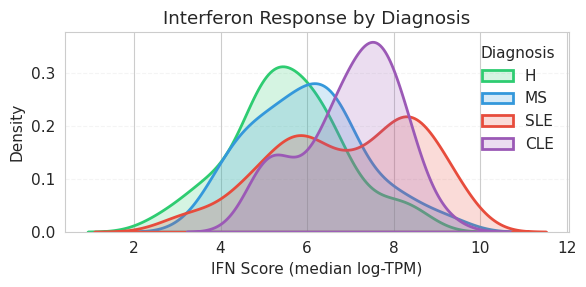


IFN Score by diagnosis:
           count  mean  median   std   min   max
diagnosis                                       
CLE           62  7.00    7.26  1.11  4.68  9.22
H             59  5.55    5.39  1.29  2.64  8.42
MS            63  5.98    5.97  1.31  3.50  9.23
SLE          249  6.90    7.11  1.71  2.78  9.82


In [14]:
#  Median IFN I type score
score = log_tpm.loc[genes].median(axis=0)
ms = metadata[['diagnosis']].copy()
ms['IFN_Score'] = score
ms = ms.dropna(subset=['IFN_Score'])

# Visualisation
plt.rcParams.update({'font.size': 11})
fig, ax = plt.subplots(figsize=(6, 3))
for d in order:
    data = ms[ms['diagnosis']==d]['IFN_Score']
    if len(data)>1: sns.kdeplot(data=data, label=d, color=colors[d], linewidth=2, ax=ax, fill=True, alpha=0.2)
ax.set(xlabel='IFN Score (median log-TPM)', ylabel='Density', title='Interferon Response by Diagnosis')
ax.legend(title='Diagnosis', frameon=False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('ifn_kde_diagnosis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistic
print("\nIFN Score by diagnosis:")
print(ms.groupby('diagnosis')['IFN_Score'].agg(['count','mean','median','std','min','max']).round(2))

#### Random Forest training + thresholding (F1, CV) and Validation: Confusion Matrix, Classification Report

Optimal threshold by F1 (train): 0.670
CV AUC (5-fold): 0.996

Test Accuracy (thr=0.670): 96.8%

Classification Report (Test):
              precision    recall  f1-score   support

        High       1.00      0.95      0.98        21
         Low       0.91      1.00      0.95        10

    accuracy                           0.97        31
   macro avg       0.95      0.98      0.96        31
weighted avg       0.97      0.97      0.97        31



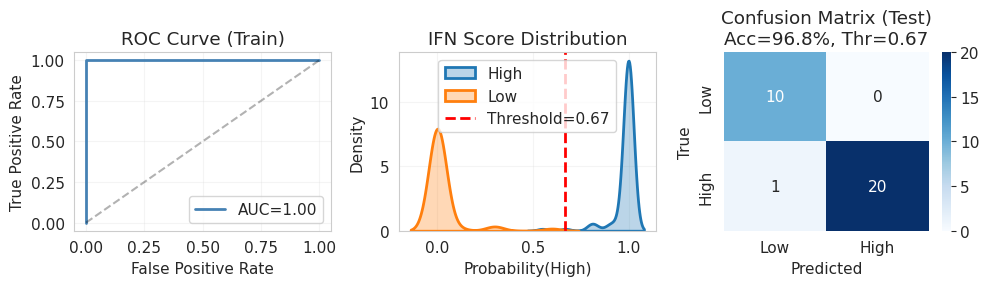


Predicted High: 202 / 433
Predicted Low:  231 / 433


In [15]:
X = log_tpm.loc[genes].T  
meta = metadata.copy()
X, meta = X.loc[meta.index], meta 
mask = meta['ifn_status'].notna()

# Train and test division
X_train, X_test, y_train, y_test = train_test_split(
    X.loc[mask], 
    meta.loc[mask, 'ifn_status'].astype(str).str.strip(),
    test_size=0.2,
    random_state=42,
    stratify=meta.loc[mask, 'ifn_status'].astype(str).str.strip()
)

# Learning of the model
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pos_idx = list(rf.classes_).index('High')

# selecting the optimal threshold on train
y_train_proba = rf.predict_proba(X_train)[:, pos_idx]
y_train_bin = (y_train == 'High').astype(int)

# Precision-Recall curve based on F1-score (on train)
prec, rec, thr_pr = precision_recall_curve(y_train_bin, y_train_proba)

#F1-score for each threshold
f1_scores = 2 * prec * rec / (prec + rec + 1e-10)

# threshold with max F1 
if len(thr_pr) > 0:
    optimal_thr = thr_pr[np.argmax(f1_scores[:-1])]
else:
    optimal_thr = 0.5  # fallback

print(f"Optimal threshold by F1 (train): {optimal_thr:.3f}")

# Evaluation of threshold stability through cross-validation
# Cross-validation to estimate AUC and stability of probabilities
cv = StratifiedKFold(n_splits=min(5, len(X_train)//3), shuffle=True, random_state=42)
cv_proba = cross_val_predict(rf, X_train, y_train, cv=cv, method='predict_proba')[:, pos_idx]

cv_auc = roc_auc_score(y_train_bin, cv_proba)
print(f"CV AUC (5-fold): {cv_auc:.3f}")

# final threshold
THRESHOLD = optimal_thr  # or other 

# Probabilities on the entire dataset (for visualization)
proba_all = rf.predict_proba(X)[:, pos_idx]

# Forecasts on the test with the selected threshold
y_test_proba = rf.predict_proba(X_test)[:, pos_idx]
y_test_pred_thr = np.where(y_test_proba >= THRESHOLD, 'High', 'Low')

# Test metrics
acc_test = (y_test == y_test_pred_thr).mean()
print(f"\nTest Accuracy (thr={THRESHOLD:.3f}): {acc_test:.1%}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_thr))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# ROC Curve on train
fpr, tpr, _ = roc_curve(y_train_bin, y_train_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr,tpr):.2f}', color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', 
            title='ROC Curve (Train)')
axes[0].legend(); axes[0].grid(alpha=0.2)

# KDE distribution 
dfk = pd.DataFrame({
    'p': proba_all[mask], 
    'lbl': meta.loc[mask, 'ifn_status']
})
for label in ['High', 'Low']:
    sns.kdeplot(
        data=dfk[dfk['lbl']==label]['p'], 
        label=label, fill=True, alpha=0.3, 
        ax=axes[1], linewidth=2
    )
axes[1].axvline(THRESHOLD, color='red', ls='--', lw=2, label=f'Threshold={THRESHOLD:.2f}')
axes[1].set(xlabel='Probability(High)', ylabel='Density', title='IFN Score Distribution')
axes[1].legend(); axes[1].grid(alpha=0.2)

# Confusion Matrix (on test)
cm = confusion_matrix(y_test, y_test_pred_thr, labels=['Low','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Low','High'], yticklabels=['Low','High'])
axes[2].set(title=f'Confusion Matrix (Test)\nAcc={acc_test:.1%}, Thr={THRESHOLD:.2f}', 
            xlabel='Predicted', ylabel='True')

plt.tight_layout()
# plt.savefig('rf_ifn_classifier.png', dpi=300, bbox_inches='tight')
plt.show()

# Applying a threshold to all samples (including unlabeled ones)

meta['IFN_Probability'] = proba_all
meta['Predicted_IFN_status'] = np.where(proba_all >= THRESHOLD, 'High', 'Low')
print(f"\nPredicted High: {(meta['Predicted_IFN_status']=='High').sum()} / {len(meta)}")
print(f"Predicted Low:  {(meta['Predicted_IFN_status']=='Low').sum()} / {len(meta)}")

meta['Predicted_IFN_status'] = np.where(proba_all >= THRESHOLD, 'High', 'Low')
meta['IFN_Probability'] = proba_all
# meta.to_csv('metadata_with_predictions.csv', sep=',', index=True)

 #### Interpretation: SHAP, Gini importance, gene correlation

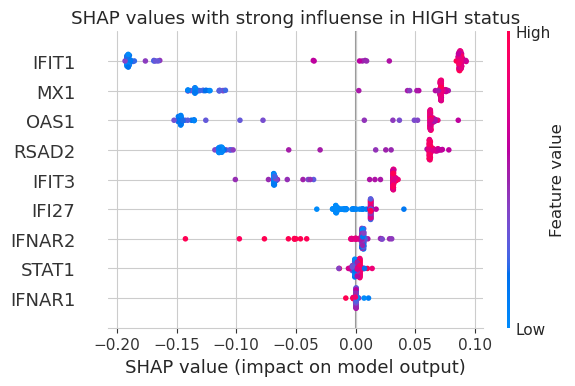

In [16]:
# SHAP values for samples with known 'High' status 
explainer = shap.TreeExplainer(rf) # rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
raw = explainer.shap_values(X_train) # X_tr, y_tr = X.loc[mask], meta.loc[mask, 'ifn_status'].astype(str).str.strip()

high_idx = list(rf.classes_).index('High')
shap_high = np.array(raw)[:, :, high_idx] if isinstance(raw, np.ndarray) and raw.ndim == 3 else np.array(raw[high_idx])

X_mat, features = X_train.values, X_train.columns.tolist()

# Visualisation
shap.summary_plot(shap_high, X_mat, feature_names=features, show=False, plot_size=(6, 4))
plt.title('SHAP values with strong influense in HIGH status')
plt.tight_layout()
#plt.savefig('shap_ifn_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

Top-5 (Gini impurity):
Geneid
IFIT1    0.282
MX1      0.205
OAS1     0.183
RSAD2    0.169
IFIT3    0.107
dtype: float64


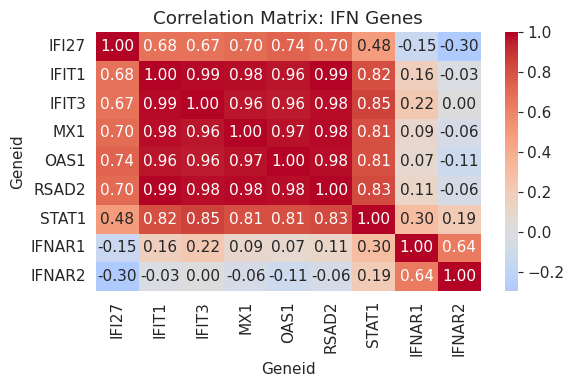

In [17]:
# Most importante genes for model (RF)
# (Gini) 
top_gini = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head()
print("Top-5 (Gini impurity):")
print(top_gini.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: IFN Genes')
plt.tight_layout(); plt.show()

A fairly large period of thresholds does not include any observations. I'm shifting towards highs to reduce the positives.

Genes "IFIT1", "RSAD2", "OAS1", and "MX1, make a significant contribution to the “high” status. Reflects the same top-5 genes for the model (feature_importances_).

#### Distibution of predicted  IFN status across diagnosis

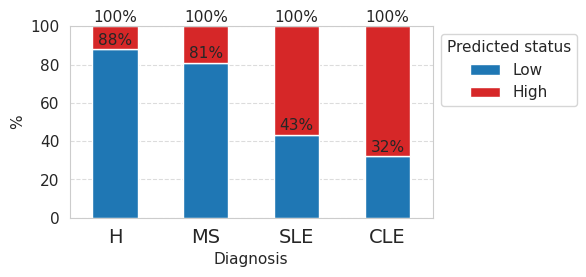

In [18]:
plot_data = pd.crosstab(meta['diagnosis'], meta['Predicted_IFN_status'], normalize='index') * 100
plot_data = plot_data.reindex(['H', 'MS', 'SLE', 'CLE']).fillna(0)
if 'Low' in plot_data.columns and 'High' in plot_data.columns:
    plot_data = plot_data[['Low', 'High']]

# Visualisation
fig, ax = plt.subplots(figsize=(6, 3))
plot_data.plot(kind='bar', stacked=True, ax=ax, 
               color=['#1f77b4', '#d62728'], edgecolor='white')

ax.set_xlabel('Diagnosis')
ax.set_ylabel('%')
ax.legend(title='Predicted status', labels=['Low', 'High'], 
          loc='upper left', bbox_to_anchor=(1.0, 1))
ax.grid(axis='y', alpha=0.67, linestyle='--')
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=1, fontsize=11)

plt.tight_layout()
plt.xticks(fontsize=14, rotation=0)
# plt.savefig('ifn_status_by_diagnosis.png', dpi=300, bbox_inches='tight')
plt.show()

####  Visualization of IFN Probability predictions by Batch/Diagnosis

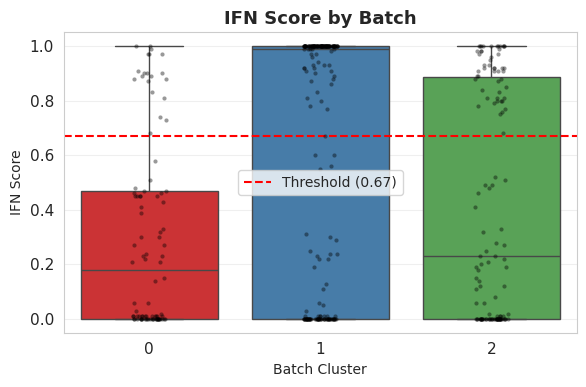

In [19]:
plt.figure(figsize=(6, 4))

# Boxplot 
sns.boxplot(data=meta, x='Batch', y='IFN_Probability', palette='Set1', order=['0', '1', '2'])
sns.stripplot(data=meta, x='Batch', y='IFN_Probability', color='black', size=3, alpha=0.4, jitter=True)

# # Visualisation
plt.axhline(0.67, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.67)')
plt.ylabel('IFN Score', fontsize=10)
plt.xlabel('Batch Cluster', fontsize=10)
plt.title('IFN Score by Batch', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('ifn_score_by_gmm_batch.png', dpi=300, bbox_inches='tight')
plt.show()

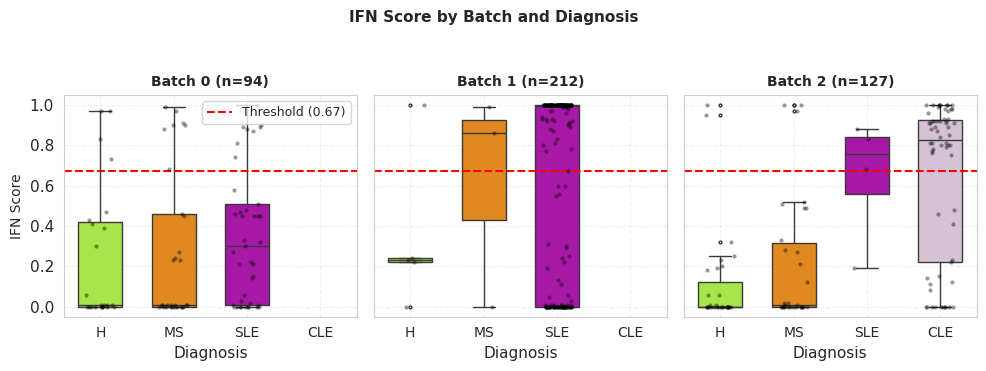

In [20]:
diag_colors = {'H': 'greenyellow', 'MS': 'darkorange', 'SLE': 'm', 'CLE': 'thistle'}
THRESHOLD = 0.67
order_diag = ['H', 'MS', 'SLE', 'CLE']

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)
fig.suptitle('IFN Score by Batch and Diagnosis', fontsize=11, fontweight='bold', y=1.05)

batches = sorted(meta['Batch'].astype(str).unique())
for ax, batch in zip(axes, batches):
    subset = meta[meta['Batch'].astype(str) == batch]
    n = len(subset)
    
    # Boxplot
    sns.boxplot(data=subset, x='diagnosis', y='IFN_Probability', 
                order=order_diag, palette=diag_colors, ax=ax, width=0.6, linewidth=1, fliersize=2)
    
    # Stripplot 
    sns.stripplot(data=subset, x='diagnosis', y='IFN_Probability', 
                  order=order_diag, color='black', size=3, alpha=0.4, jitter=0.2, ax=ax)
    
    # THRESHOLD 
    ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({THRESHOLD})')
    
    # panel
    ax.set_title(f'Batch {batch} (n={n})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Diagnosis')
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # legend
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=9)

axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[0].set_ylabel('IFN Score', fontsize=10)

plt.tight_layout()
# plt.savefig('ifn_by_batch_3panels.png', dpi=300, bbox_inches='tight')
plt.show()

In all visualizations where IFN score is taken into account, a gap is visible